# Assignment 2 on Fitting and Alignment

### Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

### Question 1

In [ ]:
file_path = 'lines.csv'

D = np.genfromtxt(file_path, delimiter=',', skip_header=1)

print("Shape of dataset:", D.shape)
print("\nFirst 5 rows:\n")
print(D[:5])

Shape of dataset: (100, 6)

First 5 rows:

[[ -5.30547099  -4.06009155  -5.26129006 -12.66633342  -3.79615021
    3.69171161]
 [ -5.5403588   -5.0031803   -3.99259187 -11.00772693  -3.98562503
    4.90000402]
 [ -4.98212753  -4.58449362  -4.33122591 -11.69731474  -3.58927699
    5.04686274]
 [ -4.49570614  -5.06413838  -4.78201809 -11.97801037  -3.59707103
    4.63593624]
 [ -4.44215386  -4.41137023  -4.5675092  -12.41495176  -2.79950409
    4.73969871]]


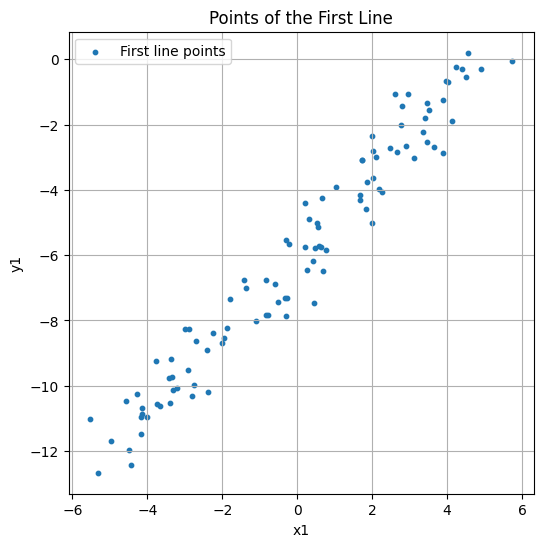

In [4]:
x1 = D[:, 0]
y1 = D[:, 3]

plt.figure(figsize=(6, 6))
plt.scatter(x1, y1, s=10, label='First line points')
plt.xlabel('x1')
plt.ylabel('y1')
plt.title('Points of the First Line')
plt.legend()
plt.grid(True)
plt.show()

Total Least Squares for one line

In [5]:
def fit_tls_line(x, y):
    points = np.column_stack((x, y))
    
    # centroid
    centroid = points.mean(axis=0)
    
    # center points
    centered = points - centroid
    
    # SVD
    _, _, vt = np.linalg.svd(centered)
    
    # line normal vector
    a, b = vt[-1]
    
    # c from centroid
    c = -(a * centroid[0] + b * centroid[1])
    
    return a, b, c, centroid

Compute TLS parameters for the first line

In [6]:
a, b, c, centroid = fit_tls_line(x1, y1)

print("TLS line parameters (ax + by + c = 0):")
print("a =", a)
print("b =", b)
print("c =", c)

# also show slope-intercept form if possible
if abs(b) > 1e-8:
    m = -a / b
    d = -c / b
    print("\nSlope-intercept form:")
    print("y = {:.6f}x + {:.6f}".format(m, d))
else:
    print("\nThis line is close to vertical, so slope-intercept form is not stable.")

TLS line parameters (ax + by + c = 0):
a = 0.7735616496467872
b = -0.6337210539312553
c = -3.794192210845812

Slope-intercept form:
y = 1.220666x + -5.987165


Plot the fitted TLS line for part (a)

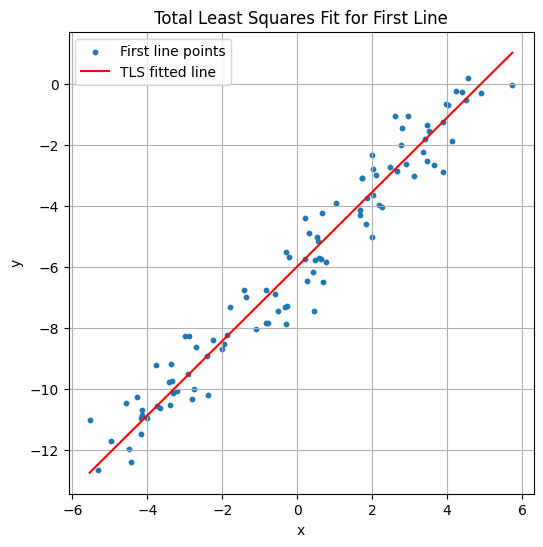

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(x1, y1, s=10, label='First line points')

x_plot = np.linspace(x1.min(), x1.max(), 200)

if abs(b) > 1e-8:
    y_plot = (-a * x_plot - c) / b
    plt.plot(x_plot, y_plot, 'r', label='TLS fitted line')
else:
    x_vertical = np.full(200, -c / a)
    y_plot = np.linspace(y1.min(), y1.max(), 200)
    plt.plot(x_vertical, y_plot, 'r', label='TLS fitted line')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Total Least Squares Fit for First Line')
plt.legend()
plt.grid(True)
plt.show()

Part (b): flatten all points

Total number of points: 300


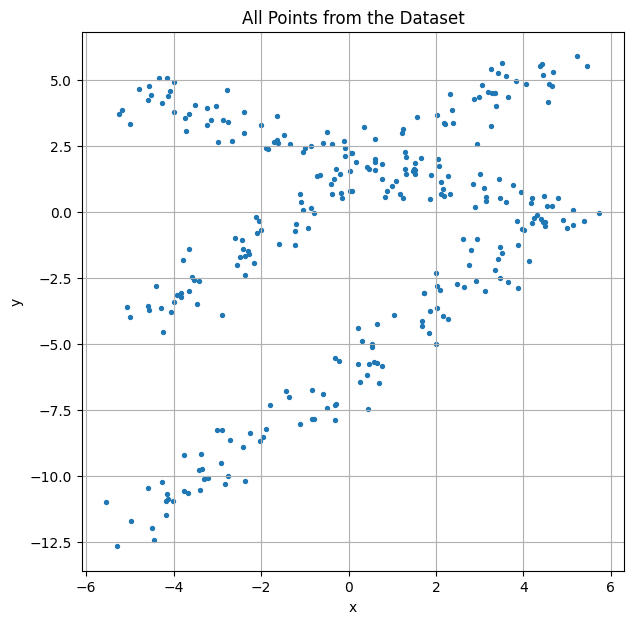

In [8]:
X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

print("Total number of points:", len(X_all))

plt.figure(figsize=(7, 7))
plt.scatter(X_all, Y_all, s=8)
plt.xlabel('x')
plt.ylabel('y')
plt.title('All Points from the Dataset')
plt.grid(True)
plt.show()

Use RANSAC three times to find three lines

In [ ]:
%pip install scikit-learn

In [ ]:
from sklearn.linear_model import RANSACRegressor, LinearRegression

remaining_x = X_all.copy()
remaining_y = Y_all.copy()

lines = []
inlier_sets = []

for i in range(3):
    X_input = remaining_x.reshape(-1, 1)
    y_input = remaining_y
    
    ransac = RANSACRegressor(
        estimator=LinearRegression(),
        min_samples=2,
        residual_threshold=0.2,
        random_state=42 + i
    )
    
    ransac.fit(X_input, y_input)
    
    inlier_mask = ransac.inlier_mask_
    outlier_mask = ~inlier_mask
    
    m = ransac.estimator_.coef_[0]
    c_line = ransac.estimator_.intercept_
    
    lines.append((m, c_line))
    inlier_sets.append((remaining_x[inlier_mask], remaining_y[inlier_mask]))
    
    print(f"Line {i+1}: y = {m:.6f}x + {c_line:.6f}")
    print(f"  Number of inliers: {inlier_mask.sum()}")
    
    # remove inliers, keep only remaining points for next iteration
    remaining_x = remaining_x[outlier_mask]
    remaining_y = remaining_y[outlier_mask]

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.5 MB ? eta -:--:--
    --------------------------------------- 0.5/36.5 MB 2.1 MB/s eta 0:00:18
   - -------------------------------------- 1.0/36.5 MB 1.9 MB/s eta 0:00:19
   - -------------------------------------- 1.3/36.5 MB 1.7 MB/s eta 0:00:21
   - -------------------------------------- 1.6/36.5 MB 1.7 MB/s eta 0:00:21
   -- ------------------------------------- 1.8/36.5 MB 1.7 MB/s eta 0:00:21
   -- ------------------------------------- 2.4/36.5 MB 1.7 MB/s eta 0:00:21
   -- ------------------------------------- 2.6/36.5 MB 1.7 MB/s eta 0


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Line 1: y = -0.549082x + 1.967696
  Number of inliers: 33
Line 2: y = -0.442100x + 2.226328
  Number of inliers: 30
Line 3: y = 1.023228x + 0.898633
  Number of inliers: 28


Plot the three detected lines and inlier groups

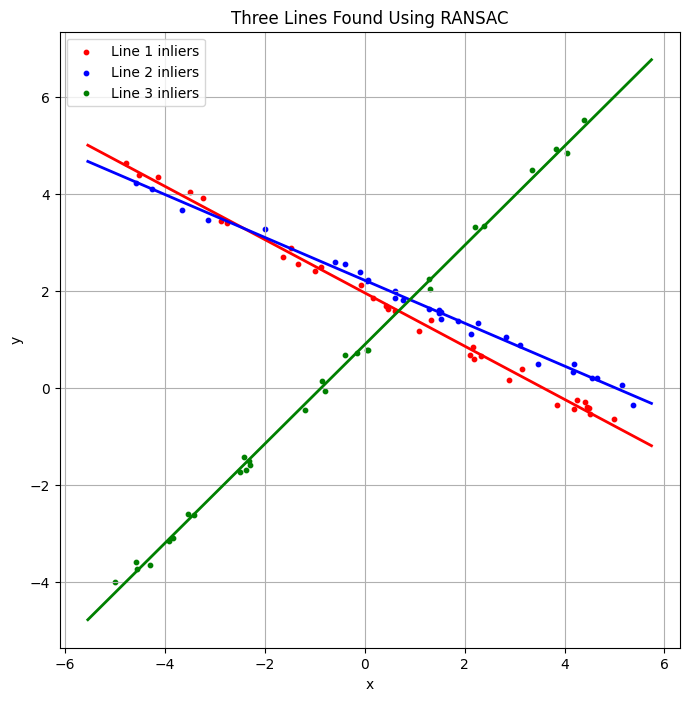

In [11]:
colors = ['red', 'blue', 'green']

plt.figure(figsize=(8, 8))

# plot each inlier group
for i, ((xin, yin), color) in enumerate(zip(inlier_sets, colors)):
    plt.scatter(xin, yin, s=10, color=color, label=f'Line {i+1} inliers')

# plot each fitted line
x_plot = np.linspace(X_all.min(), X_all.max(), 300)
for i, ((m, c_line), color) in enumerate(zip(lines, colors)):
    y_plot = m * x_plot + c_line
    plt.plot(x_plot, y_plot, color=color, linewidth=2)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Three Lines Found Using RANSAC')
plt.legend()
plt.grid(True)
plt.show()

For part (a), I used only the points in the first line, which are stored in columns x1 and y1.
Then I applied Total Least Squares (TLS) to fit a line. Unlike ordinary least squares, TLS considers error in both x and y directions. The fitted line was obtained in the form:

ax + by + c = 0

and it can also be written in slope-intercept form if the line is not vertical.

For part (b), I used all points from the dataset by flattening the three x-columns and three y-columns into one set of points. Then I applied RANSAC to find one line at a time. After finding a line, I removed its inlier points and ran RANSAC again on the remaining points. Repeating this process three times gave the three main lines in the dataset.

This method works well because RANSAC is robust to outliers and can separate multiple line groups step by step.

RANSAC was applied repeatedly to detect one line at a time. After each detected line, its inlier points were removed and RANSAC was run again on the remaining points. The final result correctly identified three lines: two with negative slope and one with positive slope. The inlier points are closely distributed around each fitted line, showing that the approach successfully separated the three line structures.

### 